a)
<img src="sheet03_1a.jpg" alt="1a" width="800" style="display: block; margin: auto;">

b) 
<img src="sheet03_1b.jpg" alt="1b" width="800" style="display: block; margin: auto;">


c) median velocity v_{0.5}

In [1]:
import numpy as np
import scipy as sc

In [2]:
def helpfunction(u):
    return 4*np.pi**(-1/2)*u**2*np.exp(-u**2)
def median_integral(u_int):
    return sc.integrate.quad(helpfunction, 0, u_int)[0] - 0.5
print("v_0.5 =", sc.optimize.root_scalar(median_integral, bracket=[0,2])["root"], "v_m")

v_0.5 = 1.0876520317581673 v_m


d) FWHM 

In [3]:
def half_height(u_func):
    return helpfunction(1)/2-helpfunction(u_func)
print("left border:", sc.optimize.root_scalar(half_height, bracket =[0,1])["root"])
print("right border:", sc.optimize.root_scalar(half_height, bracket =[1,2])["root"])
print("width at half height:", sc.optimize.root_scalar(half_height, bracket =[1,2])["root"]-sc.optimize.root_scalar(half_height, bracket =[0,1])["root"], "v_m")

left border: 0.4816232479714112
right border: 1.6365656082224955
width at half height: 1.1549423602510842 v_m


e) 
<img src="sheet03_1e.jpg" alt="1e" width="800" style="display: block; margin: auto;">


plot with all values:

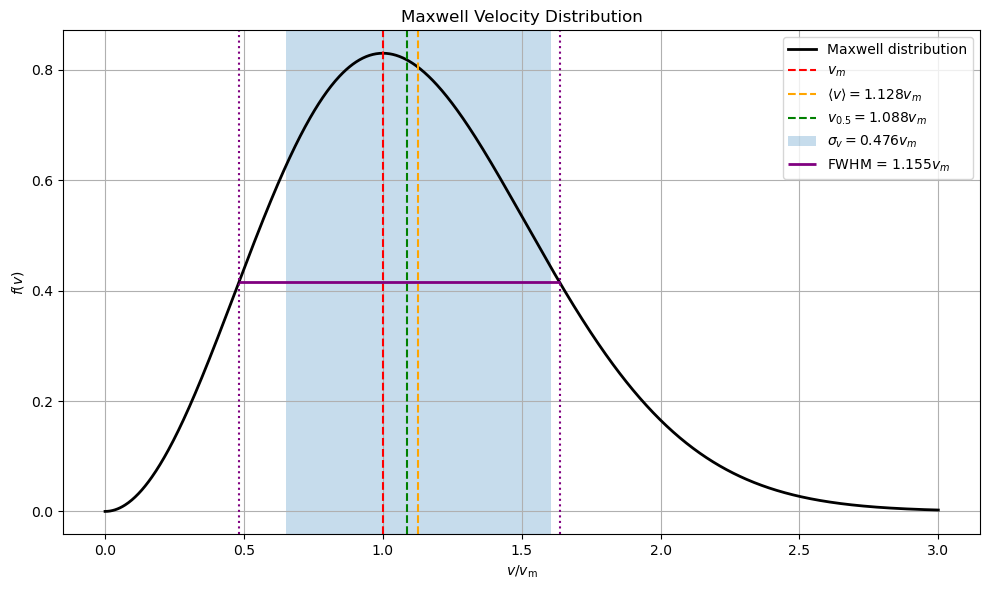

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Dimensionless units: x = v/v_m
# Set v_m = 1
vm = 1.0

# Most probable velocity
v_m = vm

# Mean velocity
v_mean = (2 / np.sqrt(np.pi)) * vm

# Median velocity
v_median = 1.0876520317581673 * vm

# Standard deviation
sigma_v = np.sqrt((3 * np.pi - 8) / (2 * np.pi)) * vm

# FWHM borders
v_left = 0.4816232479714112 * vm
v_right = 1.6365656082224955 * vm

# Width at half maximum
v_fwhm = v_right - v_left

# Maxwell distribution in units of v_m
# x = v/v_m


def f(x):
    return (4 / np.sqrt(np.pi)) * x**2 * np.exp(-x**2)

# plotting range
x = np.linspace(0, 3, 1000)
y = f(x)

# maximum and half maximum
f_max = f(v_m)
half_max = f_max / 2

plt.figure(figsize=(10, 6))

# distribution curve
plt.plot(x, y, linewidth=2,
         label="Maxwell distribution",
         color = 'k')

# v_m
plt.axvline(v_m,
            linestyle='--',
            label=r"$v_m$",
            color = 'r')

# mean velocity
plt.axvline(v_mean,
            linestyle='--',
            label=fr"$\langle v \rangle = {v_mean:.3f}v_m$",
            color = 'orange')

# median
plt.axvline(v_median,
            linestyle='--',
            label=fr"$v_{{0.5}} = {v_median:.3f}v_m$",
            color = "green")

# standard deviation region around mean
plt.axvspan(v_mean - sigma_v,
            v_mean + sigma_v,
            alpha=0.25,
            label=fr"$\sigma_v = {sigma_v:.3f}v_m$",)

# FWHM horizontal line
plt.hlines(half_max,
           v_left,
           v_right,
           linewidth=2,
           label=fr"FWHM = {v_fwhm:.3f}$v_m$",
           color = 'purple')

# FWHM borders
plt.axvline(v_left, linestyle=':', color = 'purple')
plt.axvline(v_right, linestyle=':', color = 'purple')

# labels
plt.xlabel(r"$v/v_\mathrm{m}$")
plt.ylabel(r"$f(v)$")
plt.title("Maxwell Velocity Distribution")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
import numpy as np
from scipy.integrate import quad

# -----------------------------
# Constants (example values)
# -----------------------------
kB = 1.380649e-23      # Boltzmann constant [J/K]
T = 300                # temperature [K]
m = 4.65e-26           # molecular mass [kg]
                      # example: nitrogen molecule N2

# -----------------------------
# Maxwell distribution
# -----------------------------

# Define a = m/(2k_B T)
a = m / (2 * kB * T)

# Normalization constant
N = (a / np.pi)**(3/2)

# Maxwell speed distribution
def f(v):
    return N * 4 * np.pi * v**2 * np.exp(-a * v**2)


v_mean = (2)/(np.sqrt{np.pi}) * np.sqrt{(2 * kB * T)/m}

def integrand_variance(v):
    return (v - v_mean)**2 * f(v)

variance, err = quad(integrand_variance, 0, np.inf)

sigma_v = np.sqrt(variance)

print(f"sigma_v = {sigma_v:.6e} m/s")


def integrand_skewness(v):
    return (v - v_mean)**3 * f(v)

third_central_moment, err = quad(
    integrand_skewness,
    0,
    np.inf
)

skewness = third_central_moment / sigma_v**3

print(f"Skewness = {skewness:.6f}")


def integrand_kurtosis(v):
    return (v - v_mean)**4 * f(v)

fourth_central_moment, err = quad(
    integrand_kurtosis,
    0,
    np.inf
)

kurtosis = fourth_central_moment / sigma_v**4

print(f"Kurtosis = {kurtosis:.6f}")

<v> = 4.762619e+02 m/s
sigma_v = 2.009900e+02 m/s
Skewness = 0.485693
Kurtosis = 3.108164
Excess kurtosis = 0.108164
